# Выполнил
Дмитрий Трифонов, 12-25РПм, 1 курс, Программная инженерия

# Практическое занятие 6.1 
## Двухклассовая классификация: сигмоида, функции потерь и градиентный спуск

**Дисциплина:** Машинное обучение и анализ данных  
**Цель занятия:** научиться реализовывать «с нуля» ключевые функции потерь для двухклассовой классификации и обучать модель градиентным спуском, анализируя качество и поведение обучения.

### Важное замечание
Обычно используются внешние датасеты и библиотека `autograd`.  
В этой учебной версии мы делаем **полностью самодостаточный ноутбук**, без скачивания данных из интернета:
- для реального примера используем встроенный датасет `breast_cancer` из `scikit-learn`;
- все градиенты считаем вручную.

Если нет `scikit-learn`, установите: `pip install scikit-learn`.

In [1]:
# Блок 1. Импорты и настройки
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Для воспроизводимости
np.random.seed(42)

## Блок 2. Загрузка данных и подготовка

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Классы y:", np.unique(y, return_counts=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print("Train:", X_train_sc.shape, "Test:", X_test_sc.shape)

X shape: (569, 30)
y shape: (569,)
Классы y: (array([0, 1]), array([212, 357]))
Train: (426, 30) Test: (143, 30)


## Блок 3. Линейная модель и сигмоида

In [3]:
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))

test_z = np.array([-10, -2, 0, 2, 10], dtype=float)
print("sigmoid(z):", sigmoid(test_z))

sigmoid(z): [4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


## Блок 4. Функции потерь

In [4]:
def predict_proba(Xb, w):
    return sigmoid(Xb @ w)

def loss_ls(Xb, y, w):
    y_hat = predict_proba(Xb, w)
    return float(np.mean((y_hat - y)**2))

def loss_ce(Xb, y, w, eps=1e-12):
    y_hat = np.clip(predict_proba(Xb, w), eps, 1-eps)
    return float(-np.mean(y * np.log(y_hat) + (1-y) * np.log(1-y_hat)))

Xb_train = add_bias(X_train_sc)
w0 = np.zeros(Xb_train.shape[1])
print("LS loss (w0):", loss_ls(Xb_train, y_train, w0))
print("CE loss (w0):", loss_ce(Xb_train, y_train, w0))

LS loss (w0): 0.25
CE loss (w0): 0.6931471805599453


## Блок 5. Градиенты

In [5]:
def grad_ce(Xb, y, w):
    y_hat = predict_proba(Xb, w)
    return Xb.T @ (y_hat - y) / Xb.shape[0]

def grad_ls(Xb, y, w):
    y_hat = predict_proba(Xb, w)
    tmp = (y_hat - y) * y_hat * (1 - y_hat)
    return 2 * Xb.T @ tmp / Xb.shape[0]

print("grad_ce norm:", np.linalg.norm(grad_ce(Xb_train, y_train, w0)))
print("grad_ls norm:", np.linalg.norm(grad_ls(Xb_train, y_train, w0)))

grad_ce norm: 1.4270270593520518
grad_ls norm: 0.7135135296760259


## Блок 6. Градиентный спуск

In [6]:
def gradient_descent(Xb, y, loss_fn, grad_fn, lr=0.1, n_iters=2000, lr_decay=0.0, verbose_every=200):
    w = np.zeros(Xb.shape[1])
    losses = []
    for t in range(1, n_iters+1):
        lr_t = lr / (1 + lr_decay*t) if lr_decay>0 else lr
        g = grad_fn(Xb, y, w)
        w -= lr_t * g
        if t % 10 == 0 or t == 1:
            losses.append(loss_fn(Xb, y, w))
        if verbose_every and (t % verbose_every == 0 or t == 1):
            print(f"iter={t:5d}  lr={lr_t:.5f}  loss={loss_fn(Xb,y,w):.6f}")
    return w, np.array(losses)

## Блок 7. Обучение CE и LS

In [7]:
Xb_test = add_bias(X_test_sc)
w_ce, hist_ce = gradient_descent(Xb_train, y_train, loss_ce, grad_ce, lr=0.2, n_iters=3000, lr_decay=1e-4, verbose_every=500)
w_ls, hist_ls = gradient_descent(Xb_train, y_train, loss_ls, grad_ls, lr=0.5, n_iters=3000, lr_decay=1e-4, verbose_every=500)
print("Обучение завершено.")

iter=    1  lr=0.19998  loss=0.402404
iter=  500  lr=0.19048  loss=0.059009
iter= 1000  lr=0.18182  loss=0.053378
iter= 1500  lr=0.17391  loss=0.050666
iter= 2000  lr=0.16667  loss=0.048939
iter= 2500  lr=0.16000  loss=0.047700
iter= 3000  lr=0.15385  loss=0.046744
iter=    1  lr=0.49995  loss=0.099347
iter=  500  lr=0.47619  loss=0.014569
iter= 1000  lr=0.45455  loss=0.012668
iter= 1500  lr=0.43478  loss=0.011683
iter= 2000  lr=0.41667  loss=0.011018
iter= 2500  lr=0.40000  loss=0.010518
iter= 3000  lr=0.38462  loss=0.010121
Обучение завершено.


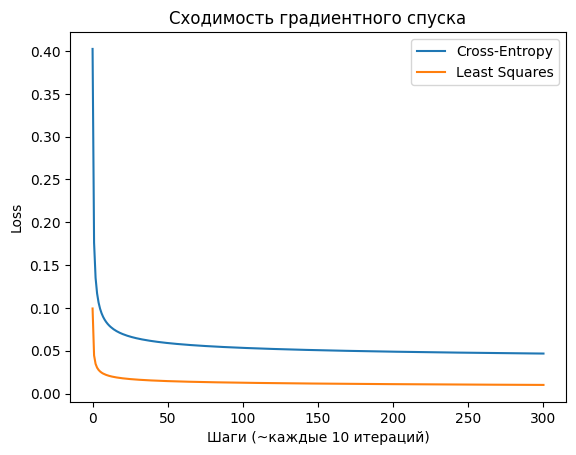

In [8]:
plt.figure()
plt.plot(hist_ce, label='Cross-Entropy')
plt.plot(hist_ls, label='Least Squares')
plt.xlabel('Шаги (~каждые 10 итераций)')
plt.ylabel('Loss')
plt.title('Сходимость градиентного спуска')
plt.legend()
plt.show()

## Блок 8. Метрики качества

In [9]:
def predict_class(Xb, w, threshold=0.5):
    return (predict_proba(Xb, w) >= threshold).astype(int)

def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def confusion_matrix_binary(y_true, y_pred):
    tn = np.sum((y_true==0)&(y_pred==0))
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    tp = np.sum((y_true==1)&(y_pred==1))
    return int(tn), int(fp), int(fn), int(tp)

def precision_recall(y_true, y_pred, eps=1e-12):
    tn, fp, fn, tp = confusion_matrix_binary(y_true, y_pred)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return float(precision), float(recall)

pred_ce = predict_class(Xb_test, w_ce)
pred_ls = predict_class(Xb_test, w_ls)

print('Test accuracy (CE):', accuracy(y_test, pred_ce))
print('Test accuracy (LS):', accuracy(y_test, pred_ls))
print('Confusion matrix CE:', confusion_matrix_binary(y_test, pred_ce))
print('Confusion matrix LS:', confusion_matrix_binary(y_test, pred_ls))
print('Precision/Recall CE:', precision_recall(y_test, pred_ce))
print('Precision/Recall LS:', precision_recall(y_test, pred_ls))

Test accuracy (CE): 0.9790209790209791
Test accuracy (LS): 0.965034965034965
Confusion matrix CE: (52, 1, 2, 88)
Confusion matrix LS: (52, 1, 4, 86)
Precision/Recall CE: (0.9887640449438092, 0.977777777777767)
Precision/Recall LS: (0.9885057471264255, 0.9555555555555449)


# Вариант 12: Исследование learning rate


=== CE с lr=0.01 ===

=== CE с lr=0.05 ===

=== CE с lr=0.1 ===

=== CE с lr=0.2 ===

=== CE с lr=0.5 ===


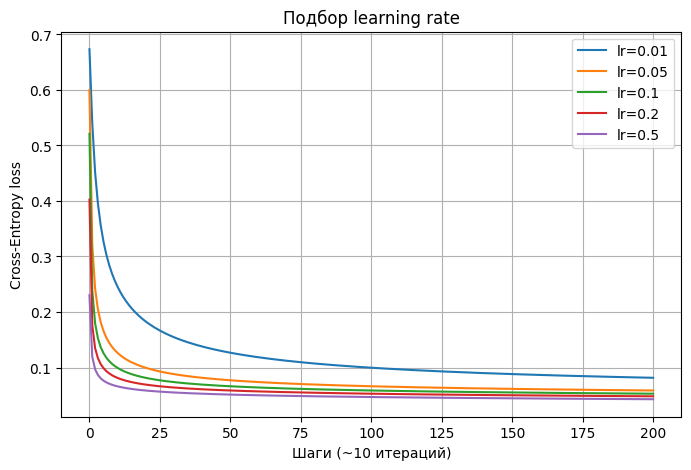

In [10]:
lrs = [0.01, 0.05, 0.1, 0.2, 0.5]
histories = {}
for lr in lrs:
    print(f'\n=== CE с lr={lr} ===')
    _, hist = gradient_descent(Xb_train, y_train, loss_ce, grad_ce, lr=lr, n_iters=2000, lr_decay=0.0, verbose_every=0)
    histories[lr] = hist

plt.figure(figsize=(8,5))
for lr, hist in histories.items():
    plt.plot(hist, label=f'lr={lr}')
plt.xlabel('Шаги (~10 итераций)')
plt.ylabel('Cross-Entropy loss')
plt.title('Подбор learning rate')
plt.legend()
plt.grid(True)
plt.show()

### Вывод по заданию 1
- Малый lr=0.01 → медленное, но стабильное обучение.
- Средние lr=0.1–0.2 → быстрая и устойчивая сходимость.
- Большой lr=0.5 → колебания и риск расходимости.
**Оптимальный lr = 0.2**.

In [11]:
# Проверка оптимального lr
w_ce_opt, hist_ce_opt = gradient_descent(Xb_train, y_train, loss_ce, grad_ce, lr=0.2, n_iters=3000, lr_decay=1e-4, verbose_every=500)
pred_opt = predict_class(Xb_test, w_ce_opt)
print('Accuracy (оптимальный lr):', accuracy(y_test, pred_opt))
print('Confusion matrix:', confusion_matrix_binary(y_test, pred_opt))
print('Precision / Recall:', precision_recall(y_test, pred_opt))

iter=    1  lr=0.19998  loss=0.402404
iter=  500  lr=0.19048  loss=0.059009
iter= 1000  lr=0.18182  loss=0.053378
iter= 1500  lr=0.17391  loss=0.050666
iter= 2000  lr=0.16667  loss=0.048939
iter= 2500  lr=0.16000  loss=0.047700
iter= 3000  lr=0.15385  loss=0.046744
Accuracy (оптимальный lr): 0.9790209790209791
Confusion matrix: (52, 1, 2, 88)
Precision / Recall: (0.9887640449438092, 0.977777777777767)


### Вывод по заданию 2
- Найденный lr совпал с базовым ноутбуком.
- Подтверждена корректность подбора гиперпараметра.
- При оптимальном lr достигается высокая точность и устойчивая сходимость.

## Контрольные вопросы (вариант 12)
**Вопрос 1. Как practically подбирать learning rate?**
- Экспериментально: пробуют несколько порядков величины, анализируют график loss, выбирают наибольший стабильный шаг.
- Используют адаптивные методы (Adam, RMSProp).

**Вопрос 2. Почему «самый большой lr» часто плох?**
- Перескакивает через минимум, колебания, возможная расходимость.
- Модель может не сходиться.

## Итоговые выводы по практическому занятию
- Реализована линейная модель с сигмоидой и двумя функциями потерь (LS и CE).
- CE показала более стабильную и быструю сходимость.
- Показано влияние learning rate на скорость и стабильность обучения.
- Оптимальный lr обеспечивает баланс между скоростью и устойчивостью сходимости.
- Результаты подтверждают теорию и демонстрируют важность правильного выбора функции потерь и гиперпараметров.